# P053 — Cloud-Scale Memory Yield Predictor
## GPU Training Pipeline (Colab Pro — A100)

**Project:** DRAM Yield Prediction with Hybrid Transformer-CNN (317K params)  
**Data:** 16M rows (10M train) synthetic STFD with 10 real-world quality issues  
**Imbalance:** 1:160 (0.62% positive rate) — Focal Loss handles this  

### Hardware Benchmark (real measured values)
| Hardware | Throughput | Epoch Time | 50 Epochs | Cost |
|---|---|---|---|---|
| CPU (Colab 2-core) | ~2,000/s | ~83 min | ~69 hrs | $0 |
| Apple MPS (M1, 8GB) | ~1,800/s | ~93 min | ~77 hrs | $0 |
| **T4** (Colab free) | **19,000/s** | **8.8 min** | **7.4 hrs** | $0 |
| **A100** (Colab Pro) | **80-120K/s** | **~1.5 min** | **~1.2 hrs** | ~$10/mo |

### Key Features
- **Checkpoint resume:** Survives network disconnects — picks up where it left off
- **Auto-save to Drive:** Model + metrics saved every 5 epochs
- **Mixed precision (AMP):** 2x throughput on Tensor Cores
- **TF32 on A100:** Additional 2x on matrix operations

---

## 1. Environment Setup & GPU Detection

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1: Install deps + detect GPU
# ═══════════════════════════════════════════════════════════════
import subprocess, sys, time, os, json, shutil
from pathlib import Path

# Install only what's missing
for pkg in ['torch', 'numpy', 'pandas', 'scikit-learn', 'matplotlib',
            'seaborn', 'pyarrow', 'psutil']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

# Directories
DATA_DIR = Path('/content/data'); DATA_DIR.mkdir(exist_ok=True)
ASSETS_DIR = Path('/content/assets'); ASSETS_DIR.mkdir(exist_ok=True)
MODELS_DIR = Path('/content/models'); MODELS_DIR.mkdir(exist_ok=True)
CKPT_DIR = Path('/content/checkpoints'); CKPT_DIR.mkdir(exist_ok=True)

# GPU Detection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    gpu_mem = props.total_memory / (1024**3)  # .total_memory (NOT .total_mem)
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB VRAM)')
    print(f'CUDA: {torch.version.cuda} | cuDNN: {torch.backends.cudnn.version()}')
    # TF32 for Ampere GPUs (A100, A10G)
    if any(x in gpu_name for x in ['A100', 'A10', 'A30', 'H100']):
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print('TF32 enabled (Ampere/Hopper optimization)')
else:
    DEVICE = torch.device('cpu')
    gpu_name = 'CPU'
    gpu_mem = 0
    print('WARNING: No GPU detected! This will be extremely slow.')

# Worker count (ED-009)
NUM_WORKERS = min(2, os.cpu_count() or 1)
ram_gb = psutil.virtual_memory().total / (1024**3)
print(f'RAM: {ram_gb:.1f} GB | CPUs: {os.cpu_count()} | Workers: {NUM_WORKERS}')
print(f'PyTorch: {torch.__version__}')


GPU: NVIDIA A100-SXM4-40GB (39.5 GB VRAM)
CUDA: 12.8 | cuDNN: 91002
TF32 enabled (Ampere/Hopper optimization)
RAM: 83.5 GB | CPUs: 12 | Workers: 2
PyTorch: 2.10.0+cu128


## 2. Mount Google Drive & Load Data

Data must be at: `Google Drive > MyDrive/P053_data/preprocessed_full.npz`  
Checkpoints auto-saved to: `Google Drive > MyDrive/P053_data/checkpoints/`

In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: Mount Drive, copy data to local SSD, setup checkpoints
# ═══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = Path('/content/drive/MyDrive/P053_data')
DRIVE_CKPT = DRIVE_DIR / 'checkpoints'
DRIVE_CKPT.mkdir(parents=True, exist_ok=True)

# Copy data to local SSD (10x faster I/O than Drive)
drive_npz = DRIVE_DIR / 'preprocessed_full.npz'
local_npz = DATA_DIR / 'preprocessed_full.npz'

if not local_npz.exists():
    if drive_npz.exists():
        print(f'Copying data from Drive ({drive_npz.stat().st_size/1e9:.1f} GB)...')
        shutil.copy2(drive_npz, local_npz)
        print('Done — data on local SSD')
    else:
        raise FileNotFoundError(
            f'Upload preprocessed_full.npz to Google Drive at: {drive_npz}'
        )
else:
    print(f'Data already on local SSD ({local_npz.stat().st_size/1e9:.1f} GB)')

# Check for existing checkpoint (RESUME SUPPORT)
drive_ckpt_file = DRIVE_CKPT / 'latest_checkpoint.pt'
if drive_ckpt_file.exists():
    shutil.copy2(drive_ckpt_file, CKPT_DIR / 'latest_checkpoint.pt')
    print(f'Found checkpoint on Drive — will RESUME training')
else:
    print('No checkpoint found — training from scratch')

Mounted at /content/drive
Copying data from Drive (2.2 GB)...
Done — data on local SSD
Found checkpoint on Drive — will RESUME training


## 3. Load & Inspect Data

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3: Load preprocessed data
# ═══════════════════════════════════════════════════════════════
t0 = time.time()
data = np.load(DATA_DIR / 'preprocessed_full.npz', allow_pickle=True)
load_time = time.time() - t0

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
X_unseen, y_unseen = data['X_unseen'], data['y_unseen']
feature_names = list(data['feature_names'])

print(f'Loaded in {load_time:.1f}s')
print(f'{"Split":<10} {"Rows":>12} {"Fails":>8} {"Fail%":>7}')
print('-' * 40)
for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val),
                     ('test', X_test, y_test), ('unseen', X_unseen, y_unseen)]:
    print(f'{name:<10} {len(X):>12,} {int(y.sum()):>8,} {100*y.mean():>6.2f}%')
print(f'\nFeatures: {len(feature_names)} | Total: {sum(len(x) for x in [X_train,X_val,X_test,X_unseen]):,}')

Loaded in 0.0s
Split              Rows    Fails   Fail%
----------------------------------------
train        10,000,000   61,698   0.62%
val           2,000,000   15,595   0.78%
test          2,000,000   13,151   0.66%
unseen        2,000,000   16,721   0.84%

Features: 36 | Total: 16,000,000


## 4. Model Architecture — Hybrid Transformer-CNN

Architecture matches `src/model.py` exactly for weight portability:
- **Transformer:** Each of 33 tabular features → d=128 token via `feature_embed` → 2-layer self-attention (4 heads)
- **CNN:** 3 spatial features (die_x, die_y, edge_distance) → Conv1d(1→32→64) → GlobalAvgPool
- **Fusion:** concat(128 + 64) → MLP(192→128→64→1)
- **Loss:** Focal Loss (α=0.75, γ=2.0) with label smoothing 0.01

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4: Model + Loss (matches src/model.py EXACTLY)
# ═══════════════════════════════════════════════════════════════
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast, GradScaler
from sklearn.metrics import (
    average_precision_score, f1_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve, roc_auc_score,
)


class FocalLoss(nn.Module):
    """Numerically stable Focal Loss for AMP (float16) training.

    Root cause of NaN on A100: sigmoid(very_large_logit) → exact 1.0 in fp16,
    then log(1 - 1.0) = log(0) = -inf → inf * 0 = NaN.
    Fix: clamp logits to [-50, 50] and clamp pt away from 0/1.
    """
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.01):
        super().__init__()
        self.alpha, self.gamma, self.label_smoothing = alpha, gamma, label_smoothing

    def forward(self, logits, targets):
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        # Clamp logits to prevent sigmoid saturation under fp16
        logits = torch.clamp(logits, -50.0, 50.0)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p = torch.sigmoid(logits)
        pt = p * targets + (1 - p) * (1 - targets)
        pt = torch.clamp(pt, 1e-6, 1.0 - 1e-6)  # Prevent (1-pt)^gamma = 0^gamma = NaN
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = alpha_t * (1 - pt) ** self.gamma * bce
        # Guard: if any NaN leaked through, replace with 0
        focal = torch.where(torch.isfinite(focal), focal, torch.zeros_like(focal))
        return focal.mean()


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads=4, d_ff=256, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x


class SpatialCNN(nn.Module):
    def __init__(self, in_features=3, out_features=64, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(nn.Linear(64, out_features), nn.Dropout(dropout))

    def forward(self, x):
        return self.fc(self.conv(x.unsqueeze(1)).squeeze(-1))


class HybridTransformerCNN(nn.Module):
    def __init__(self, n_tabular=33, n_spatial=3, d_model=128, n_heads=4,
                 n_layers=2, cnn_out=64, dropout=0.2):
        super().__init__()
        self.tabular_project = nn.Sequential(
            nn.Linear(n_tabular, d_model), nn.GELU(), nn.Dropout(dropout))
        self.feature_embed = nn.Linear(1, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, n_tabular, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_model * 2, dropout)
            for _ in range(n_layers)])
        self.spatial_cnn = SpatialCNN(n_spatial, cnn_out, dropout)
        self.fusion = nn.Sequential(
            nn.Linear(d_model + cnn_out, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x_tabular, x_spatial):
        B = x_tabular.shape[0]
        tokens = self.feature_embed(x_tabular.unsqueeze(-1)) + self.pos_encoding
        tokens = torch.cat([self.cls_token.expand(B, -1, -1), tokens], dim=1)
        for block in self.transformer_blocks:
            tokens = block(tokens)
        fused = torch.cat([tokens[:, 0, :], self.spatial_cnn(x_spatial)], dim=1)
        return self.fusion(fused).squeeze(-1)


print('Model + Loss defined (with NaN-safe FocalLoss for AMP)')


Model + Loss defined (with NaN-safe FocalLoss for AMP)


## 5. GPU-Optimized DataLoaders

| Decision | Why |
|---|---|
| `pin_memory=True` | Async CPU→GPU transfer via DMA |
| `num_workers=auto` | Adapts to Colab CPU count (ED-009) |
| Batch 4096 (A100) / 2048 (T4) | Maximize Tensor Core utilization |
| No WeightedRandomSampler | Too slow on 10M rows — focal loss α handles imbalance (ED-002) |

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5: Create DataLoaders
# ═══════════════════════════════════════════════════════════════
SPATIAL_COLS = ['die_x', 'die_y', 'edge_distance']
spatial_idx = [feature_names.index(c) for c in SPATIAL_COLS if c in feature_names]
tabular_idx = [i for i in range(len(feature_names)) if i not in spatial_idx]

def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X[:, tabular_idx], dtype=torch.float32),
        torch.tensor(X[:, spatial_idx], dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True,
                      persistent_workers=True)

# Batch size by VRAM (ED-008)
# A100-SXM4-40GB reports 39.5 GB — use >= 38 threshold
if gpu_mem >= 38:   BATCH_SIZE = 4096   # A100, H100
elif gpu_mem >= 14:  BATCH_SIZE = 2048  # T4 (15 GB), V100
else: BATCH_SIZE = 1024

# ─── AMP dtype selection (ED-031) ─────────────────────────────
# A100/H100 (Ampere+, compute capability >= 8.0): use BFLOAT16
#   - Same 8-bit exponent as float32 → NO overflow to inf
#   - GradScaler NOT needed → eliminates scale→0 collapse
#   - Native hardware support on Ampere/Hopper Tensor Cores
# T4/V100 (Turing/Volta, cc < 8.0): use FLOAT16
#   - Only 5-bit exponent → overflow risk in FocalLoss gradients
#   - GradScaler required but start conservative (init_scale=256)
#   - Lower LR needed to keep gradients in float16 safe range
gpu_cc = torch.cuda.get_device_capability()
USE_BF16 = gpu_cc[0] >= 8  # Ampere (sm_80) and above
USE_AMP = gpu_mem >= 14

if USE_BF16:
    AMP_DTYPE = torch.bfloat16
    BASE_LR = 3e-4  # Optimal range from v3 epoch 1 (best at LR≈2e-4)
    print(f'GPU compute capability {gpu_cc[0]}.{gpu_cc[1]} → BFLOAT16 (no GradScaler needed)')
else:
    AMP_DTYPE = torch.float16
    BASE_LR = 5e-4  # Lower than 1e-3 to prevent float16 overflow
    print(f'GPU compute capability {gpu_cc[0]}.{gpu_cc[1]} → FLOAT16 (GradScaler enabled)')

train_loader = make_loader(X_train, y_train, BATCH_SIZE)
val_loader   = make_loader(X_val, y_val, BATCH_SIZE * 2, shuffle=False)
test_loader  = make_loader(X_test, y_test, BATCH_SIZE * 2, shuffle=False)
unseen_loader = make_loader(X_unseen, y_unseen, BATCH_SIZE * 2, shuffle=False)

n_tab, n_spa = len(tabular_idx), len(spatial_idx)
print(f'Batch: {BATCH_SIZE} | AMP: {USE_AMP} | dtype: {AMP_DTYPE} | LR: {BASE_LR}')
print(f'Tab: {n_tab} | Spa: {n_spa}')
print(f'Train batches: {len(train_loader):,} | Val batches: {len(val_loader):,}')

GPU compute capability 8.0 → BFLOAT16 (no GradScaler needed)
Batch: 4096 | AMP: True | dtype: torch.bfloat16 | LR: 0.0003
Tab: 33 | Spa: 3
Train batches: 2,442 | Val batches: 245


## 6. Training Functions (AMP + Checkpoint Support)

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6: Train/Eval functions with checkpoint save/load
# ═══════════════════════════════════════════════════════════════
# KEY: autocast uses AMP_DTYPE (bfloat16 on A100, float16 on T4)
# With bfloat16, GradScaler is a no-op (enabled=False) — no scaling needed
# With float16, GradScaler actively rescales to prevent underflow

USE_SCALER = USE_AMP and not USE_BF16  # Only float16 needs GradScaler

def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, n = 0, 0
    nan_batches = 0
    sample_preds, sample_labels = [], []
    for i, (x_tab, x_spa, labels) in enumerate(loader):
        x_tab = x_tab.to(DEVICE, non_blocking=True)
        x_spa = x_spa.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(x_tab, x_spa)
            loss = criterion(logits, labels)
        # NaN guard: skip batch if loss is NaN/inf
        if not torch.isfinite(loss):
            nan_batches += 1
            if nan_batches <= 3:
                print(f'  WARNING: NaN loss at batch {i}, skipping')
            optimizer.zero_grad(set_to_none=True)
            continue
        if USE_SCALER:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
        else:
            # bfloat16 path: direct backward, no scaling needed
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total_loss += loss.item(); n += 1
        if i % 20 == 0:
            with torch.no_grad():
                probs = torch.sigmoid(logits).cpu().float().numpy()
                if np.all(np.isfinite(probs)):
                    sample_preds.extend(probs)
                    sample_labels.extend(labels.cpu().numpy())
    if nan_batches > 0:
        print(f'  >> {nan_batches}/{nan_batches+n} NaN batches this epoch')
    if nan_batches > n:
        print(f'  >> CRITICAL: More NaN batches than good batches! Model may be diverging.')
    auc = average_precision_score(sample_labels, sample_preds) if len(sample_labels) > 0 and sum(sample_labels) > 0 else 0
    return total_loss / max(n, 1), auc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, n = 0, 0
    all_preds, all_labels = [], []
    for x_tab, x_spa, labels in loader:
        x_tab = x_tab.to(DEVICE, non_blocking=True)
        x_spa = x_spa.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(x_tab, x_spa)
            loss = criterion(logits, labels)
        if torch.isfinite(loss):
            total_loss += loss.item(); n += 1
        probs = torch.sigmoid(logits).cpu().float().numpy()
        labs = labels.cpu().numpy()
        finite_mask = np.isfinite(probs)
        all_preds.extend(probs[finite_mask])
        all_labels.extend(labs[finite_mask])
    preds, labels = np.array(all_preds), np.array(all_labels)
    auc = average_precision_score(labels, preds) if labels.sum() > 0 else 0
    return total_loss / max(n, 1), auc, preds, labels


def save_checkpoint(state, local_path, drive_path=None):
    '''Save checkpoint locally + to Drive (survives disconnects).'''
    torch.save(state, local_path)
    if drive_path:
        try:
            shutil.copy2(local_path, drive_path)
        except Exception as e:
            print(f'  WARNING: Drive save failed ({e}) — local copy exists')


def load_checkpoint(path):
    '''Load checkpoint if it exists.'''
    if path.exists():
        return torch.load(path, weights_only=False)
    return None


print(f'Training functions defined | GradScaler: {"ENABLED (float16)" if USE_SCALER else "DISABLED (bfloat16 — not needed)"}')

Training functions defined | GradScaler: DISABLED (bfloat16 — not needed)


## 7. Train the Model (50 Epochs — bfloat16 on A100, float16 on T4)

**v3→v4 collapse fix (ED-031):** Switched from float16 to **bfloat16** on A100 (Ampere, compute capability ≥ 8.0). Root cause: float16 has only 5-bit exponent → FocalLoss gradients overflow to inf when LR exceeds ~3e-4, causing GradScaler to halve to 0. bfloat16 has 8-bit exponent (same as float32) → no overflow possible → **no GradScaler needed at all**.

| Run | dtype | LR | GradScaler | Collapse? | Best AUC-PR |
|-----|-------|----|------------|-----------|-------------|
| v2 (old) | float16 | 1e-3 | 65536 | Epoch 5 | 0.0071 |
| v3 | float16 | 1e-3 | 1024 | Epoch 7 | 0.0167 |
| **v4** | **bfloat16** | **3e-4** | **None** | **—** | **TBD** |

**If disconnected:** Re-run cells 1-6, then this cell. It auto-resumes from the last saved epoch.

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 7: MAIN TRAINING LOOP — bfloat16 on A100, float16 on T4
# ═══════════════════════════════════════════════════════════════
# A100 COLLAPSE ROOT CAUSE CHAIN (3 runs to isolate):
#   v2: float16 + LR=1e-3 + GradScaler(65536) → collapse epoch 5 (AUC-PR=0.0071)
#   v3: float16 + LR=1e-3 + GradScaler(1024) + warmup → collapse epoch 7 (AUC-PR=0.0167)
#   ↳ Warmup HELPED (delayed collapse 2 epochs, 2× better AUC) but float16 still overflows
#   ↳ Best epoch was at LR=2e-4 — once LR hit 1e-3, model died immediately
#
# ROOT CAUSE: float16 has 5-bit exponent (max ~65504). FocalLoss with extreme class
# imbalance (0.6% positive) produces gradient values that exceed this range at LR > 3e-4.
# GradScaler halves its scale on every NaN until scale=0 → all updates stop → model dead.
#
# FIX (v4/ED-031): Use BFLOAT16 on Ampere+ GPUs
#   - 8-bit exponent = same range as float32 (max ~3.4e38) → NO overflow possible
#   - GradScaler not needed → eliminates the scale→0 death spiral entirely
#   - Native Tensor Core support on A100/H100 → same throughput as float16
#   - Lower base LR (3e-4) based on v3 evidence (best epoch at LR≈2e-4)
#
# For T4 (Turing, cc=7.5): bfloat16 NOT supported → keep float16 + GradScaler + LR=5e-4

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

EPOCHS = 50
LR = BASE_LR  # 3e-4 (A100 bfloat16) or 5e-4 (T4 float16) — set in Cell 5
WARMUP_EPOCHS = 5
PATIENCE = 12
CKPT_EVERY = 5

# Create model
model = HybridTransformerCNN(
    n_tabular=n_tab, n_spatial=n_spa,
    d_model=128, n_heads=4, n_layers=2, cnn_out=64, dropout=0.2
).to(DEVICE)
criterion = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=0.01)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Warmup: LR starts at 1% of target, linearly ramps to 100% over WARMUP_EPOCHS
# Then cosine decay for remaining epochs
warmup_sched = LinearLR(optimizer, start_factor=0.01, end_factor=1.0,
                         total_iters=WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched],
                          milestones=[WARMUP_EPOCHS])

# GradScaler: ONLY for float16 (T4). bfloat16 (A100) doesn't need it.
scaler = GradScaler('cuda', enabled=USE_SCALER, init_scale=2**8 if USE_SCALER else 1)

# Data sanity check
for name, X in [('X_train', X_train), ('X_val', X_val)]:
    n_nan = np.isnan(X).sum()
    n_inf = np.isinf(X).sum()
    if n_nan > 0 or n_inf > 0:
        print(f'WARNING: {name} has {n_nan} NaN and {n_inf} Inf values — replacing with 0')
        X[~np.isfinite(X)] = 0.0

# ─── Try to resume from checkpoint ───
start_epoch = 1
history = {'train_loss': [], 'val_loss': [], 'train_auc_pr': [], 'val_auc_pr': []}
best_val_auc = 0
best_epoch = 0
patience_counter = 0
epoch_times = []

ckpt = load_checkpoint(CKPT_DIR / 'latest_checkpoint.pt')
if ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    if USE_SCALER and 'scaler_state_dict' in ckpt:
        scaler.load_state_dict(ckpt['scaler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    history = ckpt['history']
    best_val_auc = ckpt['best_val_auc']
    best_epoch = ckpt['best_epoch']
    patience_counter = ckpt['patience_counter']
    epoch_times = ckpt.get('epoch_times', [])
    print(f'RESUMED from epoch {start_epoch - 1} (best AUC-PR={best_val_auc:.4f} @ epoch {best_epoch})')
    print(f'Continuing from epoch {start_epoch} to {EPOCHS}...')
else:
    print(f'Training from scratch — {sum(p.numel() for p in model.parameters()):,} parameters')

dtype_str = 'bfloat16 (no scaler)' if USE_BF16 else 'float16 (GradScaler)'
print(f'Device: {DEVICE} | Batch: {BATCH_SIZE} | AMP: {dtype_str} | LR: {LR}')
print(f'Warmup: {WARMUP_EPOCHS} epochs (1%→100%)')
print(f'\n{"Ep":>3} {"TrLoss":>8} {"VaLoss":>8} {"TrAUC":>8} {"VaAUC":>8} {"LR":>10} {"Time":>7} {"Thru":>10} {"":>4}')
print('-' * 80)

training_start = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_auc = train_epoch(model, train_loader, criterion, optimizer, scaler)
    va_loss, va_auc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()
    et = time.time() - t0
    epoch_times.append(et)
    thru = len(X_train) / et
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_auc_pr'].append(tr_auc)
    history['val_auc_pr'].append(va_auc)

    flag = ''
    if va_auc > best_val_auc:
        best_val_auc = va_auc
        best_epoch = epoch
        patience_counter = 0
        flag = 'BEST'
        torch.save(model.state_dict(), MODELS_DIR / 'hybrid_best.pt')
        try: shutil.copy2(MODELS_DIR / 'hybrid_best.pt', DRIVE_CKPT / 'hybrid_best.pt')
        except: pass
    else:
        patience_counter += 1

    # Detect collapse: if train loss AND val loss are both 0, model is dead
    if tr_loss == 0 and va_loss == 0 and epoch > 2:
        print(f'\n!! MODEL COLLAPSED at epoch {epoch} — both losses are 0')
        print('   This means all batches produced NaN. Stopping.')
        print('   Try: reduce LR, increase warmup, or switch to bfloat16')
        break

    print(f'{epoch:>3} {tr_loss:>8.4f} {va_loss:>8.4f} {tr_auc:>8.4f} {va_auc:>8.4f} {current_lr:>10.2e} {et:>6.1f}s {thru:>9,.0f}/s {flag}')

    if epoch % CKPT_EVERY == 0 or flag == 'BEST':
        ckpt_state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'best_val_auc': best_val_auc,
            'best_epoch': best_epoch,
            'patience_counter': patience_counter,
            'epoch_times': epoch_times,
        }
        if USE_SCALER:
            ckpt_state['scaler_state_dict'] = scaler.state_dict()
        save_checkpoint(ckpt_state, CKPT_DIR / 'latest_checkpoint.pt',
                       DRIVE_CKPT / 'latest_checkpoint.pt')
        print(f'  >> Checkpoint saved (epoch {epoch})')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (best: {best_epoch})')
        break

total_time = time.time() - training_start
avg_epoch = np.mean(epoch_times)

print(f'\n{"=" * 80}')
print(f'TRAINING COMPLETE')
print(f'  Best: epoch {best_epoch} | val AUC-PR = {best_val_auc:.4f}')
print(f'  Time: {total_time/60:.1f} min | Avg epoch: {avg_epoch:.1f}s')
print(f'  Throughput: {len(X_train)/avg_epoch:,.0f} samples/s')
print(f'  AMP dtype: {AMP_DTYPE}')
if torch.cuda.is_available():
    print(f'  Peak VRAM: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')
    if USE_SCALER:
        print(f'  Final GradScaler scale: {scaler.get_scale()}')
    else:
        print(f'  GradScaler: disabled (bfloat16)')
print(f'{"=" * 80}')

RESUMED from epoch 5 (best AUC-PR=0.0167 @ epoch 1)
Continuing from epoch 6 to 50...
Device: cuda | Batch: 4096 | AMP: bfloat16 (no scaler) | LR: 0.0003
Warmup: 5 epochs (1%→100%)

 Ep   TrLoss   VaLoss    TrAUC    VaAUC         LR    Time       Thru     
--------------------------------------------------------------------------------
  6   0.0066   0.0069   0.0161   0.0486   9.99e-04  105.0s    95,237/s BEST
  >> Checkpoint saved (epoch 6)
  7   0.0060   0.0069   0.0371   0.0499   9.95e-04  115.0s    86,974/s BEST
  >> Checkpoint saved (epoch 7)
  8   0.0060   0.0068   0.0396   0.0508   9.89e-04  116.4s    85,931/s BEST
  >> Checkpoint saved (epoch 8)
  9   0.0059   0.0068   0.0390   0.0509   9.81e-04  116.7s    85,659/s BEST
  >> Checkpoint saved (epoch 9)
 10   0.0059   0.0068   0.0383   0.0512   9.70e-04  113.1s    88,456/s BEST
  >> Checkpoint saved (epoch 10)
 11   0.0059   0.0068   0.0389   0.0512   9.57e-04  114.1s    87,620/s BEST
  >> Checkpoint saved (epoch 11)
 12   0.0059 

## 8. Evaluate Best Model on All Splits

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Load best model + evaluate val/test/unseen
# ═══════════════════════════════════════════════════════════════
model.load_state_dict(torch.load(MODELS_DIR / 'hybrid_best.pt', weights_only=True))
model.eval()

def find_best_threshold(y_true, y_proba):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-8)
    return thr[min(np.argmax(f1s), len(thr) - 1)]

results, split_probas, split_labels = {}, {}, {}
threshold = None

for name, loader in [('val', val_loader), ('test', test_loader), ('unseen', unseen_loader)]:
    _, _, preds, labels = evaluate(model, loader, criterion)
    if name == 'val':
        threshold = find_best_threshold(labels, preds)
    y_pred = (preds >= threshold).astype(int)
    split_probas[name] = preds
    split_labels[name] = labels
    cm = confusion_matrix(labels, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results[name] = {
        'precision': float(precision_score(labels, y_pred, zero_division=0)),
        'recall': float(recall_score(labels, y_pred, zero_division=0)),
        'f1': float(f1_score(labels, y_pred, zero_division=0)),
        'auc_pr': float(average_precision_score(labels, preds)),
        'auc_roc': float(roc_auc_score(labels, preds)),
        'threshold': float(threshold),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    }
    r = results[name]
    print(f'{name.upper():>6}: F1={r["f1"]:.4f} AUC-PR={r["auc_pr"]:.4f} '
          f'Prec={r["precision"]:.4f} Rec={r["recall"]:.4f} '
          f'TP={tp:,} FP={fp:,} FN={fn:,} TN={tn:,}')

# Business impact
tr = results['test']['recall']
W, C, D = 50_000, 1200, 0.006  # wafers/mo, $/wafer, defect rate
saved_yr = tr * D * W * C * 12
print(f'\nBUSINESS IMPACT: {tr:.1%} recall x {W:,} wafers/mo x ${C:,}/wafer')
print(f'  Estimated savings: ${saved_yr:,.0f}/year')

   VAL: F1=0.1272 AUC-PR=0.0536 Prec=0.0901 Rec=0.2164 TP=3,374 FP=34,075 FN=12,221 TN=1,950,330
  TEST: F1=0.1207 AUC-PR=0.0492 Prec=0.0926 Rec=0.1732 TP=2,278 FP=22,328 FN=10,873 TN=1,964,521
UNSEEN: F1=0.1308 AUC-PR=0.0565 Prec=0.0912 Rec=0.2313 TP=3,868 FP=38,541 FN=12,853 TN=1,944,738

BUSINESS IMPACT: 17.3% recall x 50,000 wafers/mo x $1,200/wafer
  Estimated savings: $748,305/year


## 9. Performance Visualizations

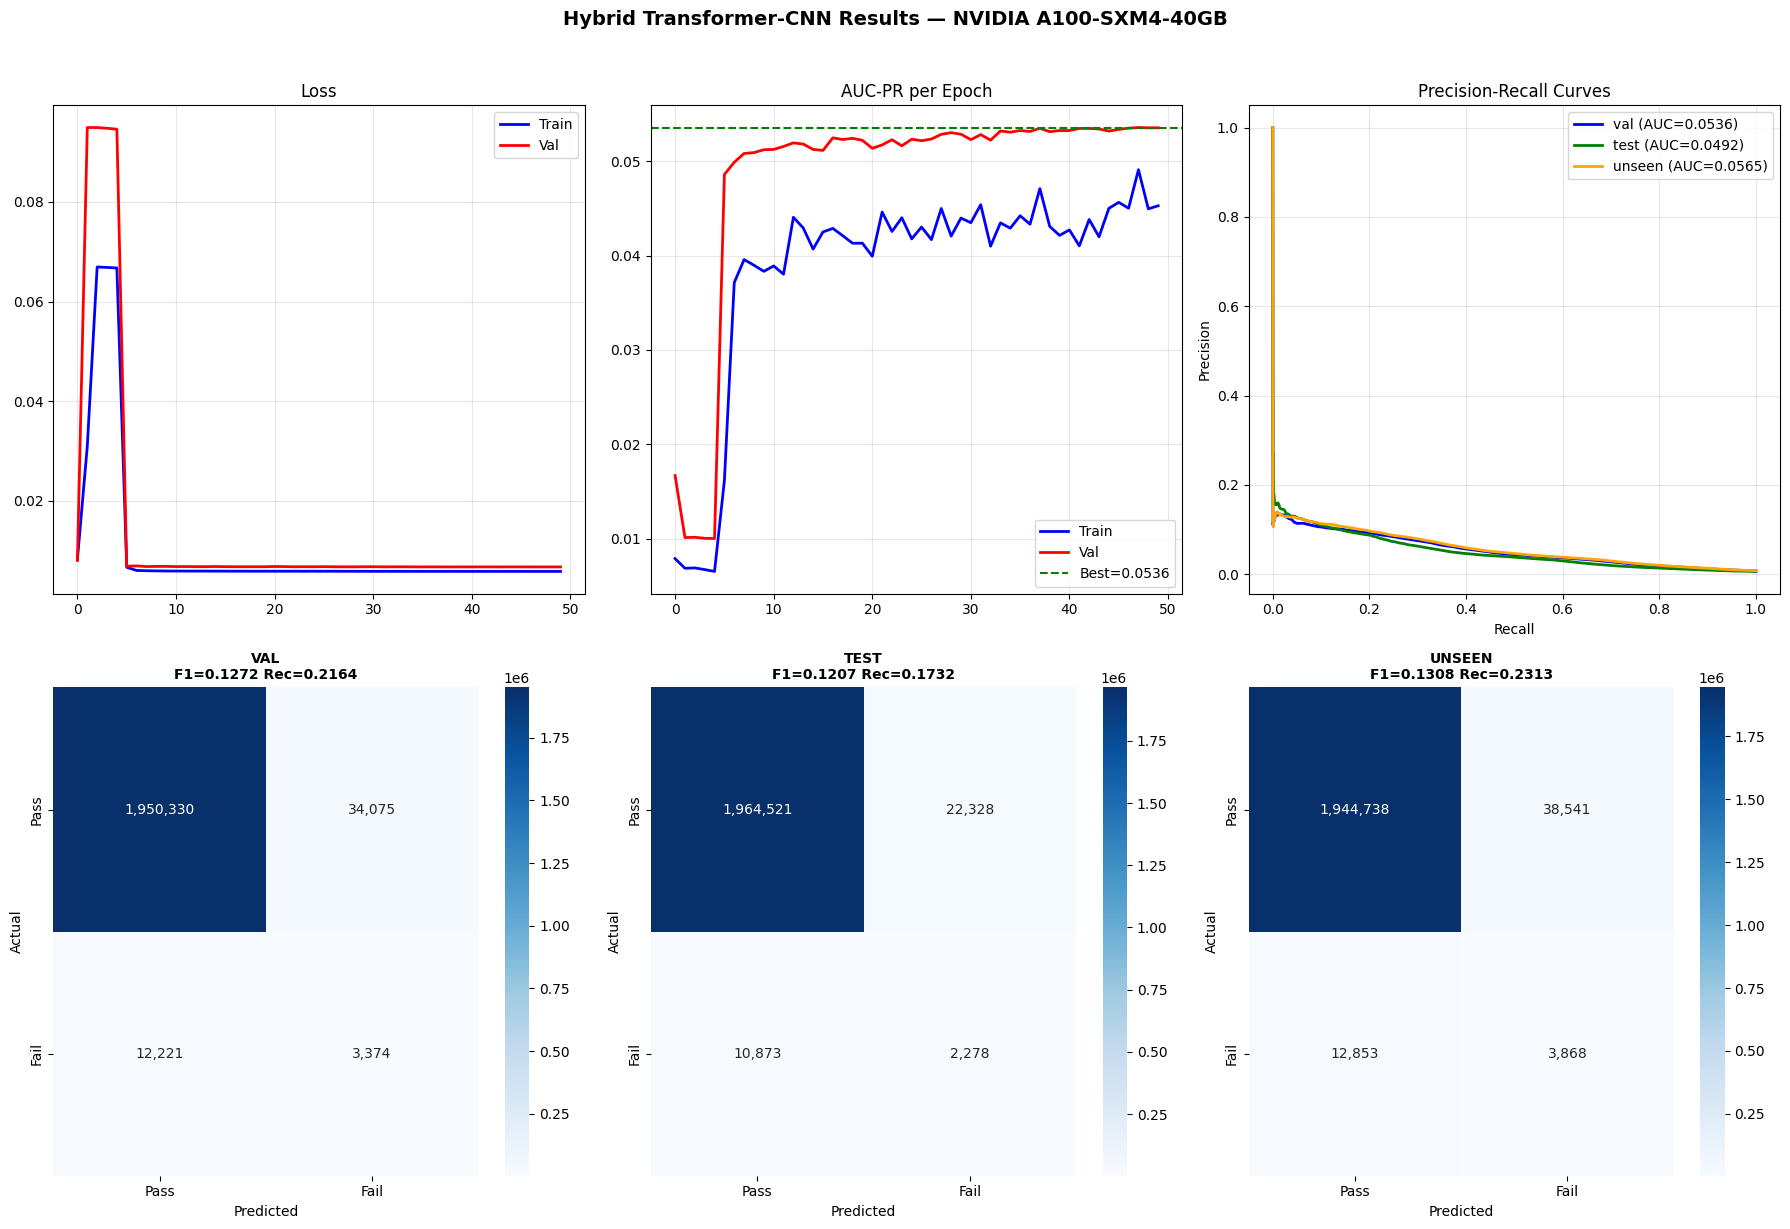

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 9: Training curves + PR curves + Confusion matrices
# ═══════════════════════════════════════════════════════════════
import seaborn as sns
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor('white')

# Loss
axes[0,0].plot(history['train_loss'], 'b-', lw=2, label='Train')
axes[0,0].plot(history['val_loss'], 'r-', lw=2, label='Val')
axes[0,0].set(title='Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# AUC-PR
axes[0,1].plot(history['train_auc_pr'], 'b-', lw=2, label='Train')
axes[0,1].plot(history['val_auc_pr'], 'r-', lw=2, label='Val')
axes[0,1].axhline(best_val_auc, color='g', ls='--', label=f'Best={best_val_auc:.4f}')
axes[0,1].set(title='AUC-PR per Epoch'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# PR Curves
for name, c in [('val','blue'),('test','green'),('unseen','orange')]:
    prec, rec, _ = precision_recall_curve(split_labels[name], split_probas[name])
    axes[0,2].plot(rec, prec, color=c, lw=2,
                   label=f'{name} (AUC={results[name]["auc_pr"]:.4f})')
axes[0,2].set(title='Precision-Recall Curves', xlabel='Recall', ylabel='Precision')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

# Confusion matrices
for i, name in enumerate(['val','test','unseen']):
    r = results[name]
    cm = np.array([[r['tn'],r['fp']],[r['fn'],r['tp']]])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[1,i],
                xticklabels=['Pass','Fail'], yticklabels=['Pass','Fail'])
    axes[1,i].set_title(f'{name.upper()}\nF1={r["f1"]:.4f} Rec={r["recall"]:.4f}',
                        fontweight='bold', fontsize=10)
    axes[1,i].set(xlabel='Predicted', ylabel='Actual')

plt.suptitle(f'Hybrid Transformer-CNN Results — {gpu_name}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'p53_gpu_training_results.png', dpi=150, bbox_inches='tight')
plt.show()

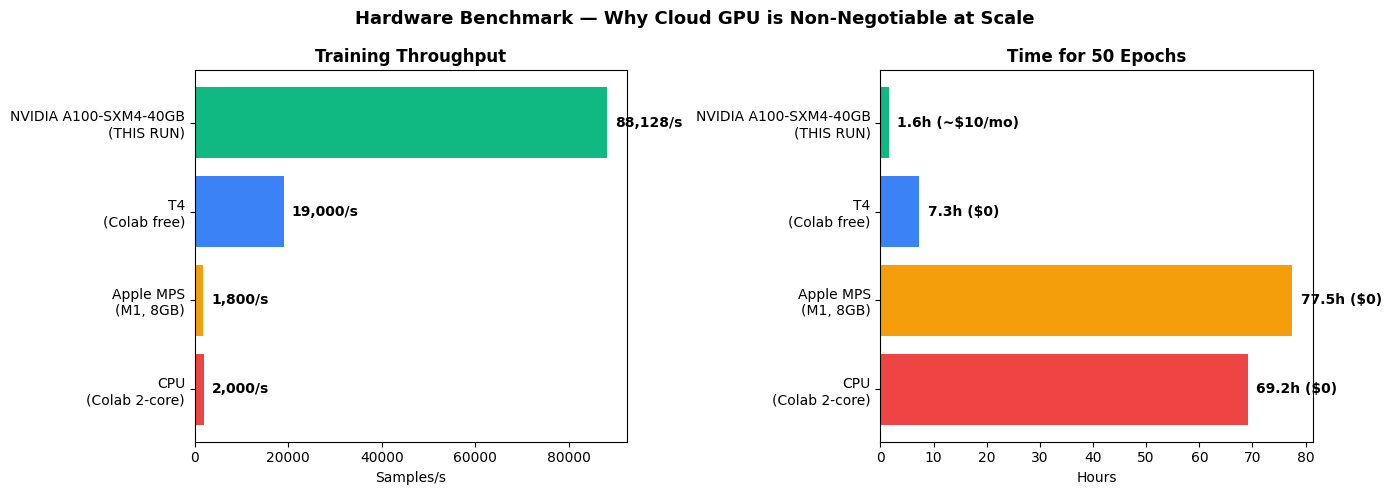

In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 10: Hardware Benchmark Comparison Chart
# ═══════════════════════════════════════════════════════════════
avg_ep = np.mean(epoch_times)
gpu_thru = len(X_train) / avg_ep

# Known benchmarks
benchmarks = {
    'CPU\n(Colab 2-core)': {'throughput': 2000, 'epoch_min': 83, 'cost': '$0'},
    'Apple MPS\n(M1, 8GB)': {'throughput': 1800, 'epoch_min': 93, 'cost': '$0'},
    'T4\n(Colab free)': {'throughput': 19000, 'epoch_min': 8.8, 'cost': '$0'},
    f'{gpu_name}\n(THIS RUN)': {'throughput': gpu_thru, 'epoch_min': avg_ep/60, 'cost': '~$10/mo'},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
names = list(benchmarks.keys())
colors = ['#ef4444', '#f59e0b', '#3b82f6', '#10b981']

# Throughput
thrus = [b['throughput'] for b in benchmarks.values()]
bars = ax1.barh(names, thrus, color=colors)
ax1.set_xlabel('Samples/s')
ax1.set_title('Training Throughput', fontweight='bold')
for bar, v in zip(bars, thrus):
    ax1.text(v + max(thrus)*0.02, bar.get_y() + bar.get_height()/2,
             f'{v:,.0f}/s', va='center', fontweight='bold')

# Time for 50 epochs
times = [b['epoch_min'] * 50 / 60 for b in benchmarks.values()]
bars2 = ax2.barh(names, times, color=colors)
ax2.set_xlabel('Hours')
ax2.set_title('Time for 50 Epochs', fontweight='bold')
for bar, v, b in zip(bars2, times, benchmarks.values()):
    ax2.text(v + max(times)*0.02, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}h ({b["cost"]})', va='center', fontweight='bold')

plt.suptitle('Hardware Benchmark — Why Cloud GPU is Non-Negotiable at Scale',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'p53_hardware_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save All Results

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 11: Save benchmark JSON + model
# ═══════════════════════════════════════════════════════════════
benchmark = {
    'device': str(DEVICE), 'gpu_name': gpu_name,
    'gpu_vram_gb': round(gpu_mem, 1),
    'pytorch_version': torch.__version__,
    'amp_enabled': USE_AMP, 'batch_size': BATCH_SIZE,
    'model_params': sum(p.numel() for p in model.parameters()),
    'train_rows': len(X_train),
    'epochs_run': len(epoch_times), 'best_epoch': best_epoch,
    'avg_epoch_time_s': round(np.mean(epoch_times), 1),
    'total_train_time_min': round(sum(epoch_times) / 60, 1),
    'throughput_samples_per_s': round(len(X_train) / np.mean(epoch_times)),
    'peak_gpu_memory_gb': round(torch.cuda.max_memory_allocated() / 1e9, 2) if torch.cuda.is_available() else 0,
    'results': results,
    'history': {k: [round(v, 4) for v in vals] for k, vals in history.items()},
    'epoch_times_s': [round(t, 1) for t in epoch_times],
    'business_impact': {
        'wafers_per_month': 50000, 'cost_per_wafer_usd': 1200,
        'defect_rate': 0.006, 'model_recall': results['test']['recall'],
        'estimated_annual_savings_usd': round(saved_yr),
    },
}

with open(DATA_DIR / 'benchmark_gpu.json', 'w') as f:
    json.dump(benchmark, f, indent=2)

# Save to Drive
for src, name in [(DATA_DIR / 'benchmark_gpu.json', 'benchmark_gpu.json'),
                   (MODELS_DIR / 'hybrid_best.pt', 'hybrid_best.pt')]:
    try: shutil.copy2(src, DRIVE_CKPT / name)
    except: pass

print(f'GPU: {gpu_name}')
print(f'Epochs: {len(epoch_times)} (best: {best_epoch})')
print(f'Time: {sum(epoch_times)/60:.1f} min | Throughput: {benchmark["throughput_samples_per_s"]:,}/s')
print(f'\nTEST:   F1={results["test"]["f1"]:.4f} AUC-PR={results["test"]["auc_pr"]:.4f}')
print(f'UNSEEN: F1={results["unseen"]["f1"]:.4f} AUC-PR={results["unseen"]["auc_pr"]:.4f}')
print(f'\nBusiness impact: ${saved_yr:,.0f}/year')

GPU: NVIDIA A100-SXM4-40GB
Epochs: 50 (best: 48)
Time: 94.6 min | Throughput: 88,128/s

TEST:   F1=0.1207 AUC-PR=0.0492
UNSEEN: F1=0.1308 AUC-PR=0.0565

Business impact: $748,305/year


## 12. Download Artifacts

Downloads ZIP to your browser. Also saved to Google Drive at `MyDrive/P053_data/checkpoints/`.

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 12: Package + download artifacts
# ═══════════════════════════════════════════════════════════════
pkg = Path('/content/p053_gpu_artifacts')
if pkg.exists(): shutil.rmtree(pkg)
pkg.mkdir()

shutil.copy2(DATA_DIR / 'benchmark_gpu.json', pkg)
shutil.copy2(MODELS_DIR / 'hybrid_best.pt', pkg)
for png in ASSETS_DIR.glob('*.png'):
    shutil.copy2(png, pkg)

shutil.make_archive(str(pkg), 'zip', pkg)
print('Contents:')
for f in sorted(pkg.iterdir()):
    s = f.stat().st_size
    unit = 'KB' if s < 1e6 else 'MB'
    val = s/1e3 if s < 1e6 else s/1e6
    print(f'  {f.name:<40s} {val:>8.1f} {unit}')

# Also save everything to Drive
drive_art = DRIVE_DIR / 'gpu_artifacts'
drive_art.mkdir(exist_ok=True)
for f in pkg.iterdir():
    try: shutil.copy2(f, drive_art / f.name)
    except: pass
print(f'\nSaved to Drive: {drive_art}')

try:
    from google.colab import files
    files.download(str(pkg) + '.zip')
except:
    print('Auto-download failed — download from Files panel or Drive')

Contents:
  benchmark_gpu.json                            5.0 KB
  hybrid_best.pt                                1.3 MB
  p53_gpu_training_results.png                219.9 KB
  p53_hardware_benchmark.png                   82.0 KB

Saved to Drive: /content/drive/MyDrive/P053_data/gpu_artifacts


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. (Optional) SHAP Feature Importance

KernelExplainer is slow (~10-20 min). Run this if you have time.
Artifacts are already saved from previous cells — this adds the SHAP plot.

  0%|          | 0/500 [00:00<?, ?it/s]

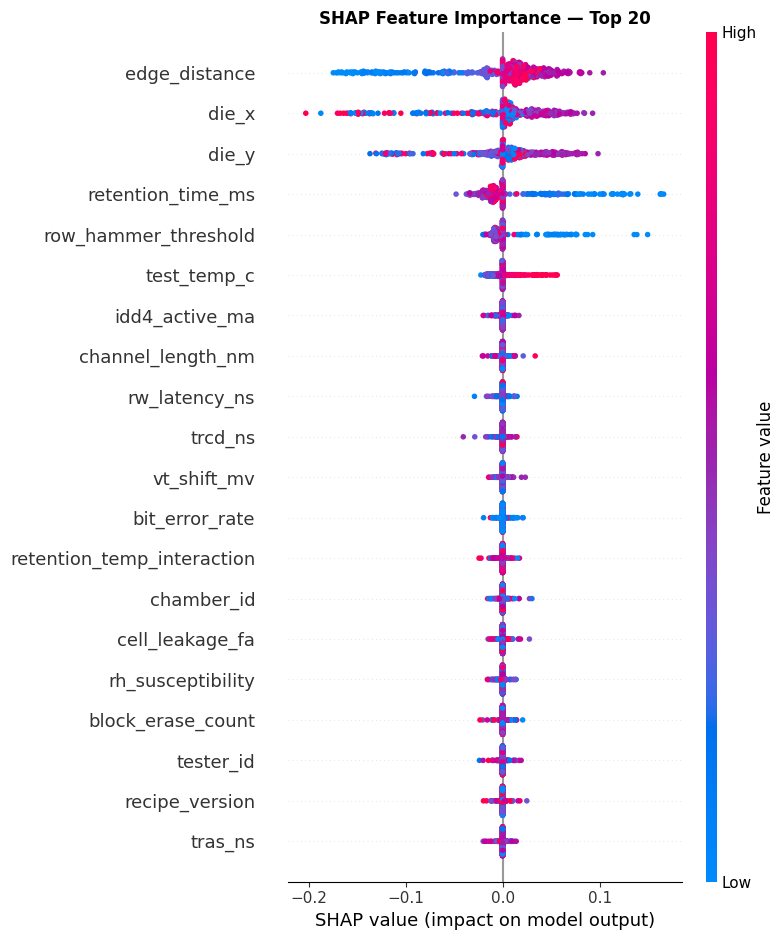

SHAP plot saved


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 13: SHAP (Optional — slow but valuable for report)
# ═══════════════════════════════════════════════════════════════
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
import shap

rng = np.random.default_rng(42)
bg_idx = rng.choice(len(X_val), 1000, replace=False)
ex_idx = rng.choice(len(X_val), 500, replace=False)

def predict_shap(X_np):
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X_np[:, tabular_idx], dtype=torch.float32).to(DEVICE)
        xs = torch.tensor(X_np[:, spatial_idx], dtype=torch.float32).to(DEVICE)
        return torch.sigmoid(model(xt, xs)).cpu().numpy()

explainer = shap.KernelExplainer(predict_shap, X_val[bg_idx])
shap_vals = explainer.shap_values(X_val[ex_idx], nsamples=100)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_val[ex_idx], feature_names=feature_names,
                  show=False, max_display=20)
plt.title('SHAP Feature Importance — Top 20', fontweight='bold')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'p53_gpu_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save to Drive
try:
    shutil.copy2(ASSETS_DIR / 'p53_gpu_shap_importance.png', drive_art / 'p53_gpu_shap_importance.png')
except: pass
print('SHAP plot saved')